In [1]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Settings after
warnings.filterwarnings('ignore')
plt.style.use('dark_background')

In [2]:
df = pd.read_csv('../data/processed/british_gp_2023_clean.csv')
df.shape

(802, 15)

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

In [4]:
df['IsOutLap'] = df['PitOutTime'].notna().astype(int)

In [5]:
df['IsInLap'] = df['PitInTime'].notna().astype(int)

In [6]:
df['TyreLifeSquared'] = df['TyreLife'] ** 2

In [7]:
print(df[['TyreLife', 'TyreLifeSquared', 'IsOutLap', 'IsInLap']].head(10))

   TyreLife  TyreLifeSquared  IsOutLap  IsInLap
0       2.0              4.0         0        0
1       3.0              9.0         0        0
2       4.0             16.0         0        0
3       5.0             25.0         0        0
4       6.0             36.0         0        0
5       7.0             49.0         0        0
6       8.0             64.0         0        0
7       9.0             81.0         0        0
8      10.0            100.0         0        0
9      11.0            121.0         0        0


In [8]:
le = LabelEncoder()
df['CompoundEncoded'] = le.fit_transform(df['Compound'].fillna('UNKNOWN'))
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'HARD': 0, 'MEDIUM': 1, 'SOFT': 2}


In [9]:
# Define features (inputs to the model)
features = [
    'LapNumber',
    'Stint',
    'TyreLife',
    'TyreLifeSquared',
    'CompoundEncoded',
    'IsOutLap',
    'IsInLap',
    'SpeedI1',
    'SpeedI2',
    'SpeedFL',
    'SpeedST',
]

# Define target (what we want to predict)
target = 'LapTimeSeconds'

In [10]:
#Remove the rows with missing values in our features
model_df = df[features + [target]].dropna()

X = model_df[features]
y = model_df[target]

#Split 80% for training and 20% for testing
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Traning samples: {len(X_train)}")
print(f"Test sample: {len(X_test)}")

Traning samples: 641
Test sample: 161


In [11]:
#baselin: predict the median lap time for every single lap
baseline_predction = np.full(len(y_test), y_train.median())

#calculate how wrong the baseline is on average
baseline_mae = mean_absolute_error(y_test, baseline_predction)

print(f"Baseline MAE :{baseline_mae:.3f}seconds")
print(f"This means just getting the median is wrong by {baseline_mae:.3f}s on average")

Baseline MAE :0.790seconds
This means just getting the median is wrong by 0.790s on average


In [12]:
#Create XGBoost model 
model = xgb.XGBRegressor(
    n_estimators = 300,       #Builds 300 trees
    max_depth = 6,            #Each tree can be 6 level deep
    learning_rate = 0.05,     #How fast it learns
    subsample = 0.8,          #Use 80% of data per tree
    random_state = 42,        #Makes results reproduciable
    n_jobs = -1               #use all CPU core
)

#Train the model
model.fit(X_train, y_train)

#Make the model predict on test set
y_pred  = model.predict(X_test)

#Calculate metrices
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)


print(f"=== MODEL RESULTS ===")
print(f"MAE : {mae:.3}seconds (baseline was {baseline_mae:.3f}s)")
print(f"RMSE: {rmse:.3f}seconds")
print(f"R2: {r2:.4f}")
print(f"Improvement over baseline: {((baseline_mae - mae)/baseline_mae)*100:.1f}%")

=== MODEL RESULTS ===
MAE : 0.313seconds (baseline was 0.790s)
RMSE: 0.453seconds
R2: 0.7975
Improvement over baseline: 60.3%


XGBoost lap time predictor — MAE: 0.313s, R2: 0.80, 60.3% improvement over baseline

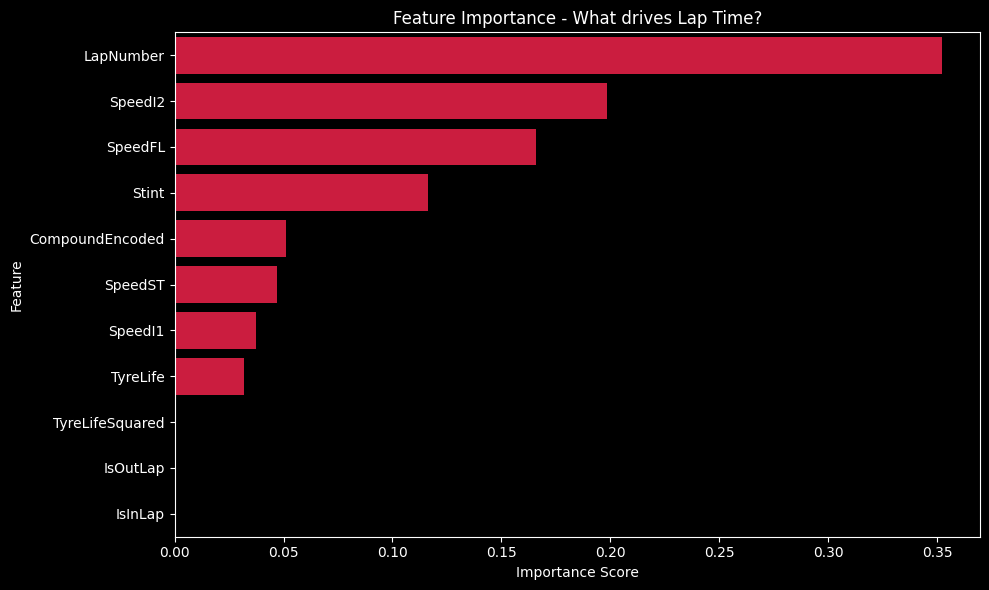

In [13]:
#Feature importance chart
importance_df = pd.DataFrame({
    'Feature':features,
    'Importance':model.feature_importances_
}).sort_values('Importance', ascending = False)

fig,ax = plt.subplots(figsize = (10,6))
sns.barplot(data=importance_df,x= 'Importance', y='Feature', color='#E8002D', ax=ax)
ax.set_title('Feature Importance - What drives Lap Time?')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [14]:
import joblib
import os

os.makedirs('../models', exist_ok=True)
joblib.dump(model, '../models/lap_time_predictor.pkl')
print('✅ Model saved!')

✅ Model saved!
